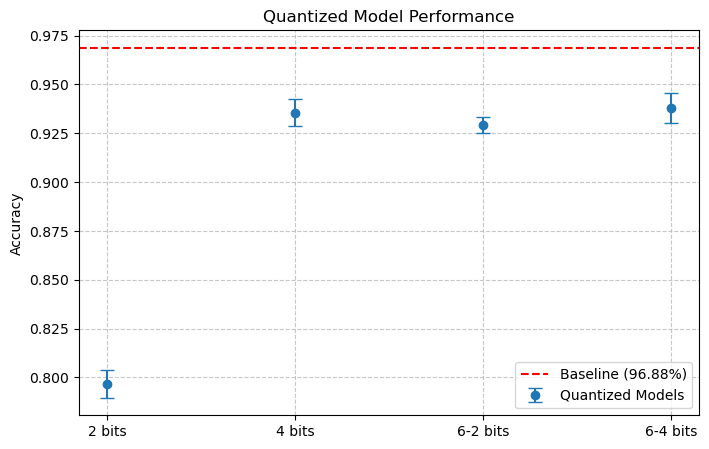

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data
categories = ['2 bits', '4 bits', '6-2 bits', '6-4 bits']
means = [0.7966, 0.9356, 0.9293, 0.9380]
confidence_intervals = [
    (0.7896, 0.8037),
    (0.9285, 0.9427),
    (0.9250, 0.9336),
    (0.9301, 0.9458)
]

# Extract lower and upper errors
lower_errors = [mean - ci[0] for mean, ci in zip(means, confidence_intervals)]
upper_errors = [ci[1] - mean for mean, ci in zip(means, confidence_intervals)]

# Baseline
baseline = 0.9688

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
x_positions = np.arange(len(categories))

# Plot means with error bars
ax.errorbar(x_positions, means, yerr=[lower_errors, upper_errors], fmt='o', capsize=5, label='Quantized Models')

# Plot baseline
ax.axhline(y=baseline, color='r', linestyle='--', label='Baseline (96.88%)')

# Labels and title
ax.set_xticks(x_positions)
ax.set_xticklabels(categories)
ax.set_ylabel('Accuracy')
ax.set_title('Quantized Model Performance')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)

# Show plot
plt.show()


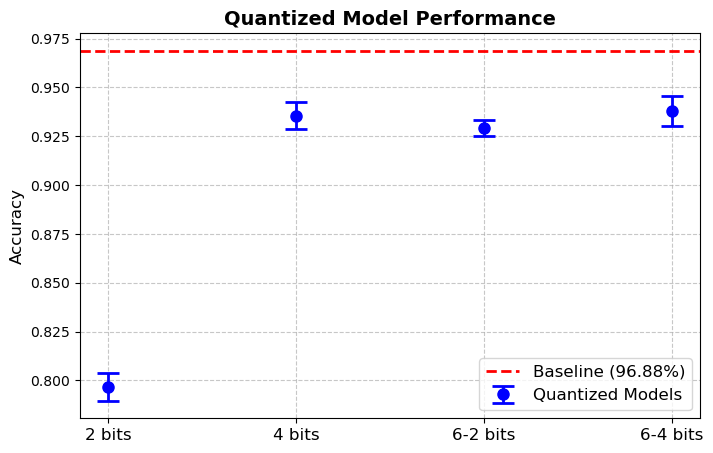

In [2]:
# Enhanced visualization with larger markers and thicker lines

fig, ax = plt.subplots(figsize=(8, 5))
x_positions = np.arange(len(categories))

# Plot means with error bars (larger markers, thicker error bars)
ax.errorbar(x_positions, means, yerr=[lower_errors, upper_errors], fmt='o', capsize=8,
            markersize=8, elinewidth=2, capthick=2, label='Quantized Models', color='blue')

# Plot baseline (thicker line)
ax.axhline(y=baseline, color='r', linestyle='--', linewidth=2, label='Baseline (96.88%)')

# Labels and title
ax.set_xticks(x_positions)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Quantized Model Performance', fontsize=14, fontweight='bold')

# Grid for better visibility
ax.grid(True, linestyle='--', alpha=0.7)

# Add a legend with a larger font size
ax.legend(fontsize=12)

# Show plot
plt.show()


In [4]:
import seaborn as sns

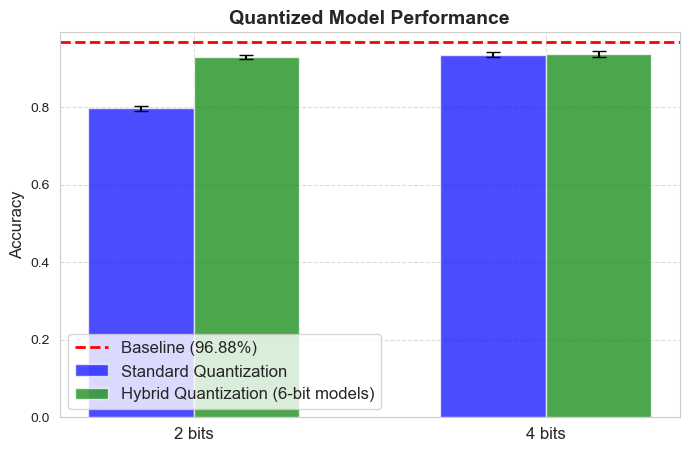

In [8]:
# Adjusted visualization with grouped bars instead of floating points

fig, ax = plt.subplots(figsize=(8, 5))

# Define x positions for 2-bit and 4-bit categories
x_positions = np.arange(2)

# Grouped bar width
bar_width = 0.3

# Means for 2-bit and 4-bit
means_2_4 = [0.7966, 0.9356]
errors_2_4 = [[0.7966 - 0.7896, 0.9356 - 0.9285], 
              [0.8037 - 0.7966, 0.9427 - 0.9356]]  # Lower and upper errors

# Means for 6-2 and 6-4 on a separate row
means_6_2_6_4 = [0.9293, 0.9380]
errors_6_2_6_4 = [[0.9293 - 0.9250, 0.9380 - 0.9301], 
                  [0.9336 - 0.9293, 0.9458 - 0.9380]]  # Lower and upper errors

# Plot bars for 2-bit and 4-bit
ax.bar(x_positions - bar_width/2, means_2_4, yerr=errors_2_4, capsize=5,
       width=bar_width, label='Standard Quantization', color='blue', alpha=0.7)

# Plot bars for 6-2bit and 6-4bit as a different category
ax.bar(x_positions + bar_width/2, means_6_2_6_4, yerr=errors_6_2_6_4, capsize=5,
       width=bar_width, label='Hybrid Quantization (6-bit models)', color='green', alpha=0.7)

# Plot baseline
ax.axhline(y=baseline, color='r', linestyle='--', linewidth=2, label='Baseline (96.88%)')

# Labels and title
ax.set_xticks(x_positions)
ax.set_xticklabels(['2 bits', '4 bits'], fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Quantized Model Performance', fontsize=14, fontweight='bold')

# Grid and legend
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=12)

# Show plot
plt.show()


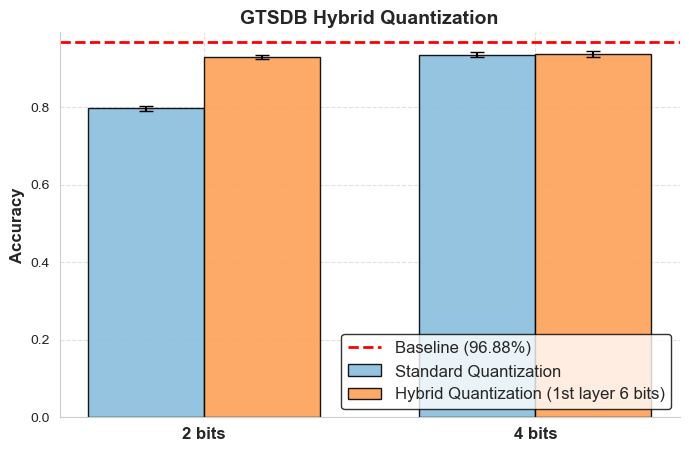

In [27]:
# Create figure with improved aesthetics
fig, ax = plt.subplots(figsize=(8, 5))

# Define x positions for 2-bit and 4-bit categories
x_positions = np.arange(2)

# Grouped bar width
bar_width = 0.35

# Define colors
color_standard = sns.color_palette("Blues")[2]
color_hybrid = sns.color_palette("Oranges")[2]

# Plot bars for standard quantization (2-bit and 4-bit)
bars1 = ax.bar(x_positions - bar_width/2, means_2_4, yerr=errors_2_4, capsize=5,
       width=bar_width, label='Standard Quantization', color=color_standard, alpha=0.9, edgecolor='black')

# Plot bars for hybrid quantization (6-2bit and 6-4bit)
bars2 = ax.bar(x_positions + bar_width/2, means_6_2_6_4, yerr=errors_6_2_6_4, capsize=5,
       width=bar_width, label='Hybrid Quantization (1st layer 6 bits)', color=color_hybrid, alpha=0.9, edgecolor='black')

# Plot baseline with improved styling
ax.axhline(y=baseline, color='red', linestyle='--', linewidth=2, label='Baseline (96.88%)')

# Labels and title with improved fonts
ax.set_xticks(x_positions)
ax.set_xticklabels(['2 bits', '4 bits'], fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('GTSDB Hybrid Quantization', fontsize=14, fontweight='bold')

# Grid styling
ax.grid(True, linestyle='--', alpha=0.6)

# Add legend with better styling
ax.legend(fontsize=12, frameon=True, loc='lower right', edgecolor='black')

# Remove top and right borders for a cleaner look
sns.despine()


plt.savefig("hybrid_quant.pdf", format='pdf', bbox_inches='tight')
# Show plot
plt.show()

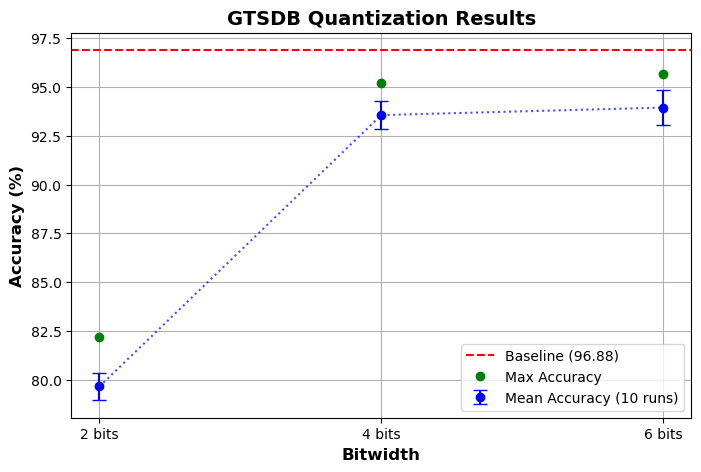

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Swap 2-bit and 6-bit values for proper ordering
bit_levels = ["2 bits", "4 bits", "6 bits"]
max_values = [82.2115, 95.192, 95.673]
means = [0.7966346204280853 * 100, 0.9355769276618957 * 100, 0.9394230782985687 * 100]
confidence_intervals = [
    (0.7895584202478966 * 100, 0.803710820608274 * 100),
    (0.9284729124469918 * 100, 0.9426809428767996 * 100),
    (0.9303672027660901 * 100, 0.9484789538310474 * 100)
]

# Update x positions
x_positions = np.arange(len(bit_levels))

# Convert confidence intervals into symmetric error values
yerr = np.array([(mean - conf[0], conf[1] - mean) for mean, conf in zip(means, confidence_intervals)]).T

# Create the updated plot
plt.figure(figsize=(8, 5))

# Plot baseline
baseline = 96.88  # Define baseline value if not already defined
plt.axhline(y=baseline, color='r', linestyle='--', label='Baseline (96.88)')

# Plot values with error bars (confidence intervals)
plt.errorbar(x_positions, means, yerr=yerr, fmt='o', capsize=5, label='Mean Accuracy (10 runs)', color='blue')

# Plot max values
plt.plot(x_positions, max_values, 'o', label='Max Accuracy', color='green')

# **Add line connecting mean values**
plt.plot(x_positions, means, linestyle='dotted', color='blue', alpha=0.7)

# Labels and title with bold font
plt.xticks(x_positions, bit_levels)
plt.ylabel("Accuracy (%)", fontsize=12, fontweight='bold')  # Bold y-axis label
plt.xlabel("Bitwidth", fontsize=12, fontweight='bold')  # Bold x-axis label
plt.title("GTSDB Quantization Results", fontsize=14, fontweight='bold')  # Bold title

# Legend and grid
plt.legend()
plt.grid(True)

# Save and show plot
plt.savefig("GTSDB_quant_results.pdf", format='pdf', bbox_inches='tight')
plt.show()


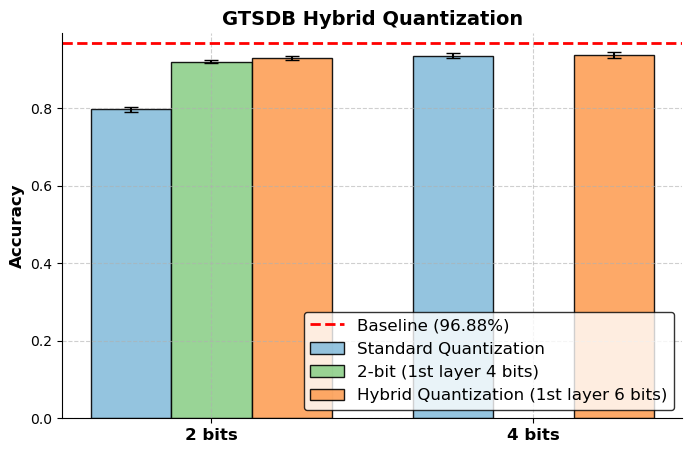

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Means for 2-bit and 4-bit
means_2_4 = [0.7966, 0.9356]
errors_2_4 = [[0.7966 - 0.7896, 0.9356 - 0.9285], 
              [0.8037 - 0.7966, 0.9427 - 0.9356]]  # Lower and upper errors

# Means for 6-2 and 6-4 on a separate row
means_6_2_6_4 = [0.9293, 0.9380]
errors_6_2_6_4 = [[0.9293 - 0.9250, 0.9380 - 0.9301], 
                  [0.9336 - 0.9293, 0.9458 - 0.9380]]  # Lower and upper errors

# New data for 2-bit with first layer at 4 bits
mean_2_4first = 0.9192
error_2_4first = (0.9231 - 0.9154) / 2  # Compute the standard error

baseline = 0.9688  # Baseline accuracy

# Create figure
fig, ax = plt.subplots(figsize=(8, 5))

# Define x positions
x_positions = np.arange(2)

# Bar width
bar_width = 0.25

# Define colors
color_standard = sns.color_palette("Blues")[2]
color_hybrid = sns.color_palette("Oranges")[2]
color_2_4first = sns.color_palette("Greens")[2]  # New color

# Plot standard quantization
ax.bar(x_positions - bar_width, means_2_4, yerr=errors_2_4, capsize=5,
       width=bar_width, label='Standard Quantization', color=color_standard, alpha=0.9, edgecolor='black')

# Plot hybrid quantization
ax.bar(x_positions, means_6_2_6_4, yerr=errors_6_2_6_4, capsize=5,
       width=bar_width, label='Hybrid Quantization (1st layer 6 bits)', color=color_hybrid, alpha=0.9, edgecolor='black')

# Plot 2-bit with first layer at 4 bits
ax.bar(x_positions[0] + bar_width, mean_2_4first, yerr=error_2_4first, capsize=5,
       width=bar_width, label='2-bit (1st layer 4 bits)', color=color_2_4first, alpha=0.9, edgecolor='black')

# Plot baseline
ax.axhline(y=baseline, color='red', linestyle='--', linewidth=2, label='Baseline (96.88%)')

# Labels and title
ax.set_xticks(x_positions)
ax.set_xticklabels(['2 bits', '4 bits'], fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('GTSDB Hybrid Quantization', fontsize=14, fontweight='bold')

# Grid styling
ax.grid(True, linestyle='--', alpha=0.6)

# Add legend
ax.legend(fontsize=12, frameon=True, loc='lower right', edgecolor='black')

# Remove top and right borders
sns.despine()

# Save and show plot
plt.savefig("hybrid_quant_updated.pdf", format='pdf', bbox_inches='tight')
plt.show()


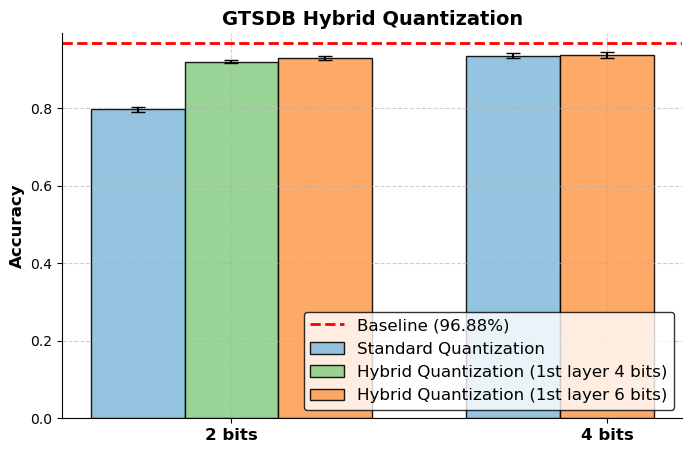

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Means for 2-bit and 4-bit standard quantization
means_2_4 = [0.7966, 0.9356]
errors_2_4 = [[0.7966 - 0.7896, 0.9356 - 0.9285], 
              [0.8037 - 0.7966, 0.9427 - 0.9356]]  # Lower and upper errors

# Means for 6-2 and 6-4 hybrid quantization
means_6_2_6_4 = [0.9293, 0.9380]
errors_6_2_6_4 = [[0.9293 - 0.9250, 0.9380 - 0.9301], 
                  [0.9336 - 0.9293, 0.9458 - 0.9380]]  # Lower and upper errors

# Data for 2-bit with first layer at 4 bits
mean_2_4first = 0.9192
error_2_4first = [(0.9192 - 0.9154), (0.9231 - 0.9192)]  # Lower and upper errors

baseline = 0.9688  # Baseline accuracy

# Create figure
fig, ax = plt.subplots(figsize=(8, 5))

# Define x positions manually to remove gaps
x_labels = ['2 bits', '4 bits']
x_positions = np.array([0, 1])  # Base positions for categories

# Adjusting widths and offsets dynamically
bar_width = 0.25

# Define colors
color_standard = sns.color_palette("Blues")[2]
color_hybrid = sns.color_palette("Oranges")[2]
color_2_4first = sns.color_palette("Greens")[2]  # New color

# Plot standard quantization (blue)
ax.bar(x_positions - bar_width, means_2_4, yerr=errors_2_4, capsize=5,
       width=bar_width, label='Standard Quantization', color=color_standard, alpha=0.9, edgecolor='black')

# Plot 2-bit (1st layer 4 bits) (green) **only in 2 bits**
ax.bar(x_positions[0], mean_2_4first, yerr=[[error_2_4first[0]], [error_2_4first[1]]], capsize=5,
       width=bar_width, label='Hybrid Quantization (1st layer 4 bits)', color=color_2_4first, alpha=0.9, edgecolor='black')

# Adjust hybrid quantization (orange) **so that it aligns properly**
ax.bar([x_positions[0] + bar_width, x_positions[1]],  # Separate X positions for 2 bits & 4 bits
       means_6_2_6_4, yerr=errors_6_2_6_4, capsize=5,
       width=bar_width, label='Hybrid Quantization (1st layer 6 bits)', color=color_hybrid, alpha=0.9, edgecolor='black')

# Plot baseline
ax.axhline(y=baseline, color='red', linestyle='--', linewidth=2, label='Baseline (96.88%)')

# Labels and title
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('GTSDB Hybrid Quantization', fontsize=14, fontweight='bold')

# Grid styling
ax.grid(True, linestyle='--', alpha=0.6)

# Add legend
ax.legend(fontsize=12, frameon=True, loc='lower right', edgecolor='black')

# Remove top and right borders
sns.despine()

# Save and show plot
plt.savefig("hybrid_quant_updated.pdf", format='pdf', bbox_inches='tight')
plt.show()


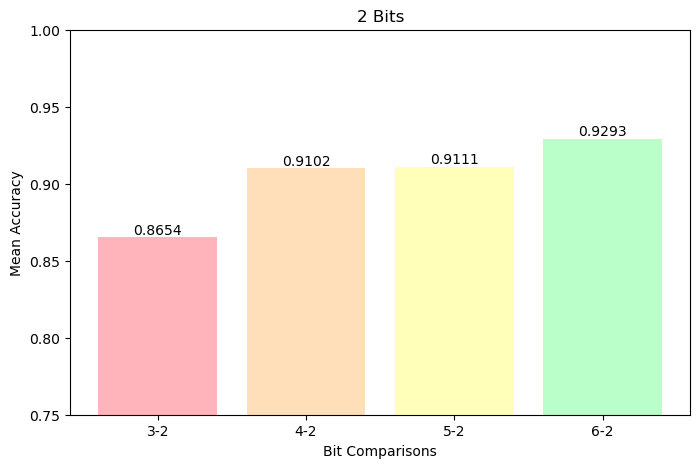

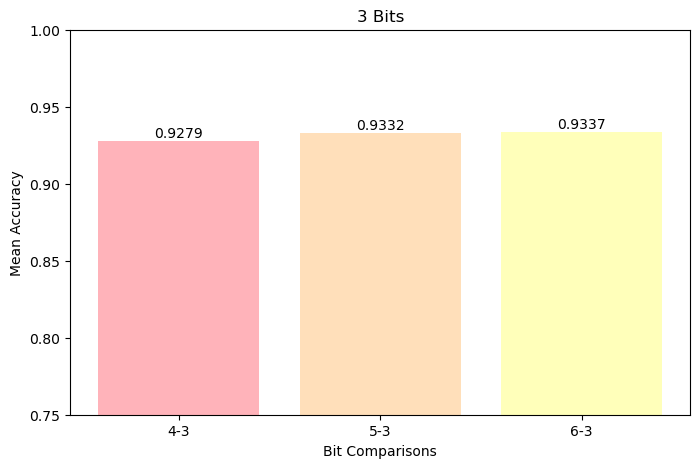

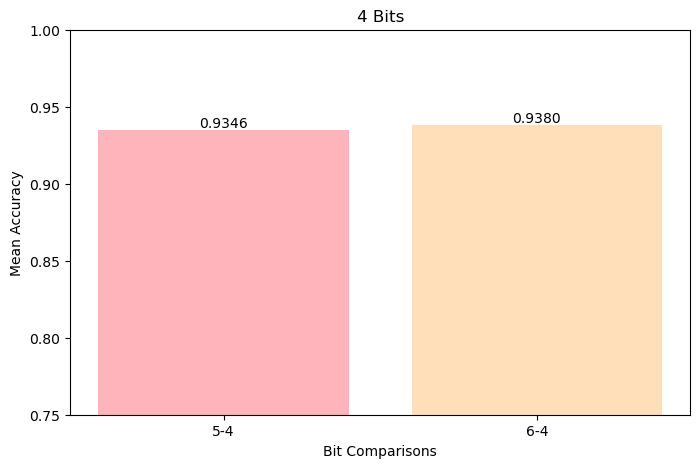

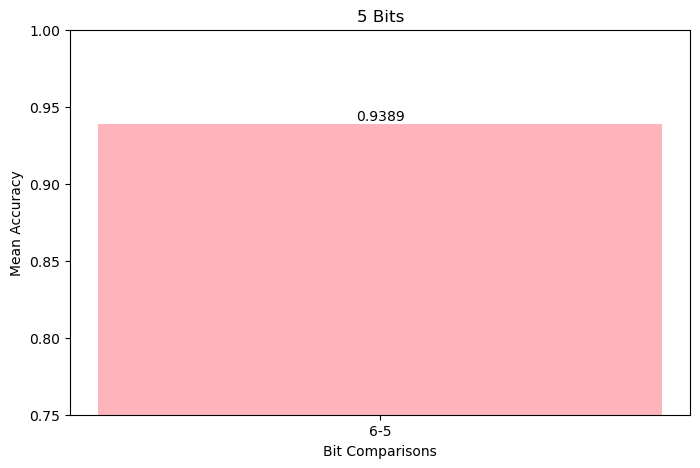

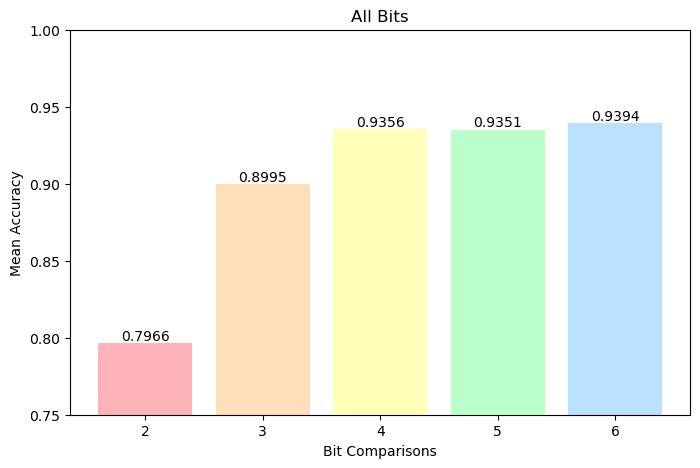

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Define data for different bit comparisons
bit_data = {
    "2 Bits": {"3-2": 0.8654, "4-2": 0.9102, "5-2": 0.9111, "6-2": 0.9293},
    "3 Bits": {"4-3": 0.9279, "5-3": 0.9332, "6-3": 0.9337},
    "4 Bits": {"5-4": 0.9346, "6-4": 0.9380},
    "5 Bits": {"6-5": 0.9389},
    "All Bits": {"2": 0.7966, "3": 0.8995, "4": 0.9356, "5": 0.9351, "6": 0.9394}
}

# Define colors (light pastel colors)
colors = [
    "#FFB3BA", "#FFDFBA", "#FFFFBA", "#BAFFC9", "#BAE1FF", 
    "#D3B8FF", "#FFCBA4", "#B5EAD7", "#C7CEEA", "#FF9AA2"
]

# Function to create bar plots
def create_bar_plot(title, data, color_palette):
    plt.figure(figsize=(8, 5))
    bars = plt.bar(data.keys(), data.values(), color=color_palette[:len(data)])
    plt.xlabel("Bit Comparisons")
    plt.ylabel("Mean Accuracy")
    plt.title(title)
    plt.ylim(0.75, 1.0)

    # Label bars with values
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.4f}", ha='center', va='bottom', fontsize=10)

    plt.show()

# Generate plots for each bit comparison
for title, data in bit_data.items():
    create_bar_plot(title, data, colors)


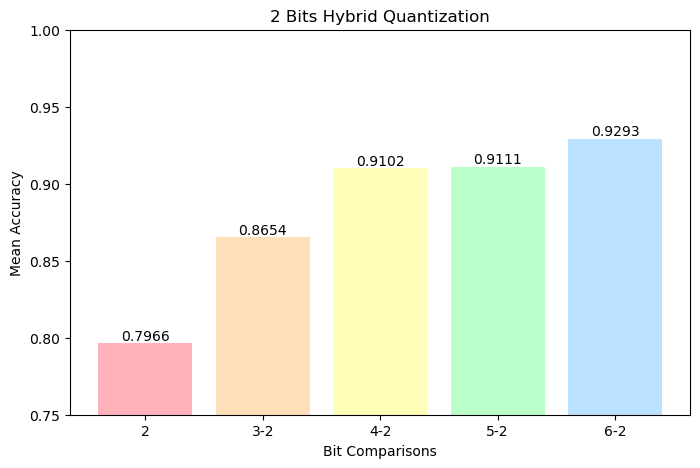

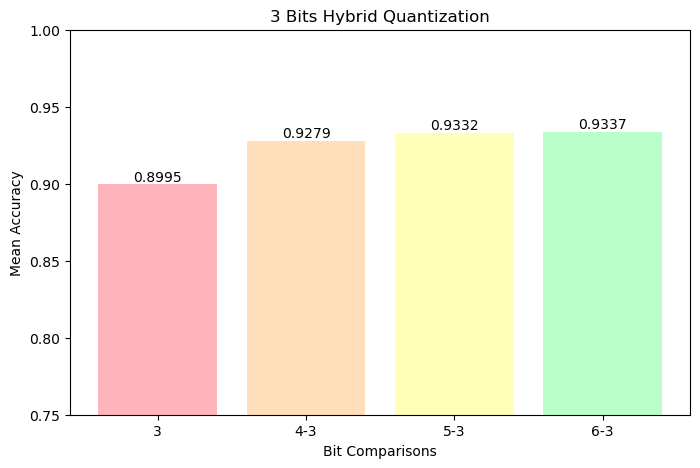

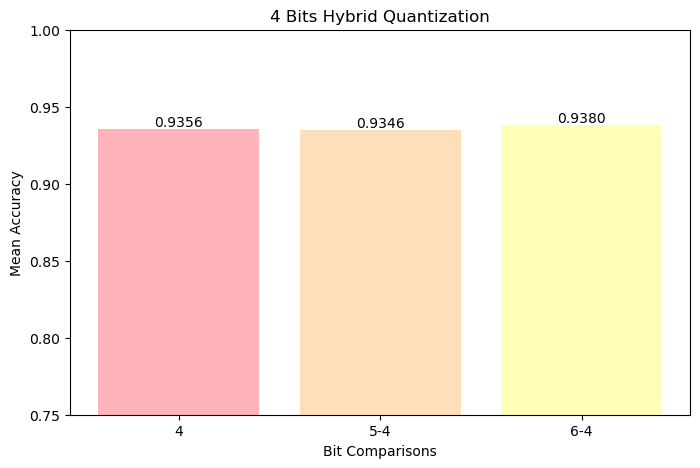

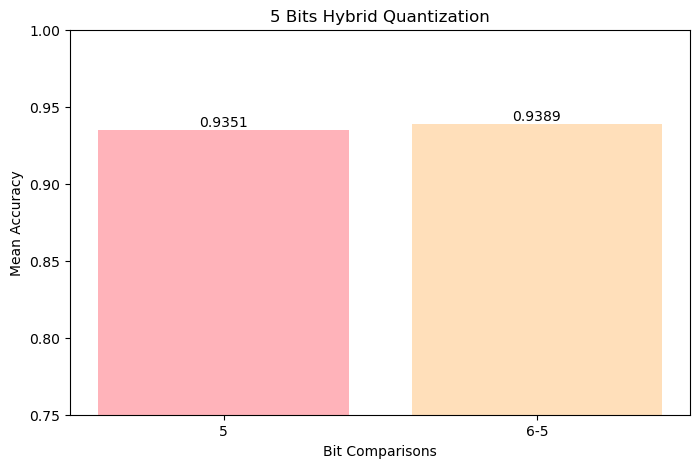

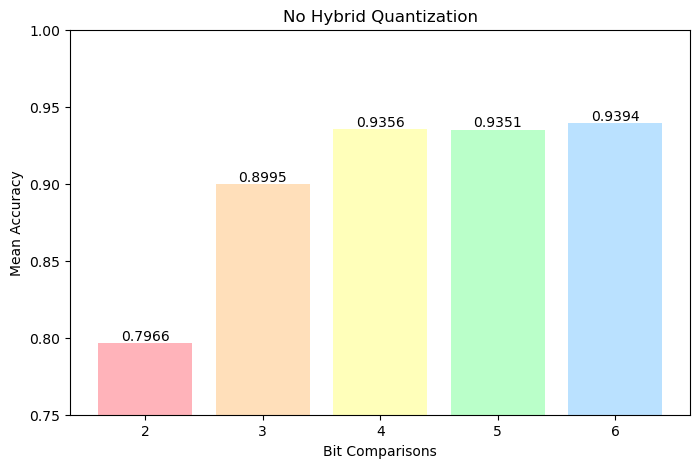

In [5]:
# Define data for different bit comparisons including the base bits

bit_data_updated = {
    "2 Bits Hybrid Quantization": {"2": 0.7966, "3-2": 0.8654, "4-2": 0.9102, "5-2": 0.9111, "6-2": 0.9293},
    "3 Bits Hybrid Quantization": {"3": 0.8995, "4-3": 0.9279, "5-3": 0.9332, "6-3": 0.9337},
    "4 Bits Hybrid Quantization": {"4": 0.9356, "5-4": 0.9346, "6-4": 0.9380},
    "5 Bits Hybrid Quantization": {"5": 0.9351, "6-5": 0.9389},
    "No Hybrid Quantization": {"2": 0.7966, "3": 0.8995, "4": 0.9356, "5": 0.9351, "6": 0.9394}
}

# Generate updated plots for each bit comparison including base bit values
for title, data in bit_data_updated.items():
    create_bar_plot(title, data, colors)


In [6]:
# Function to save bar plots as PDF
def save_bar_plot(title, data, color_palette):
    plt.figure(figsize=(8, 5))
    bars = plt.bar(data.keys(), data.values(), color=color_palette[:len(data)])
    plt.xlabel("Bit Comparisons")
    plt.ylabel("Mean Accuracy")
    plt.title(title)
    plt.ylim(0.75, 1.0)

    # Label bars with values
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.4f}", ha='center', va='bottom', fontsize=10)

    # Save figure as PDF
    filename = f"GTSDB_{title.replace(' ', '_')}.pdf"
    filepath = f"{filename}"
    plt.savefig(filepath, format="pdf")
    plt.close()

    return filepath

# Save all plots as PDF
pdf_files = []
for title, data in bit_data_updated.items():
    pdf_files.append(save_bar_plot(title, data, colors))

# Provide the saved PDF files to the user
pdf_files


['GTSDB_2_Bits_Hybrid_Quantization.pdf',
 'GTSDB_3_Bits_Hybrid_Quantization.pdf',
 'GTSDB_4_Bits_Hybrid_Quantization.pdf',
 'GTSDB_5_Bits_Hybrid_Quantization.pdf',
 'GTSDB_No_Hybrid_Quantization.pdf']